Q5] V-plot

Total unique (X, Y) pairs: 280653


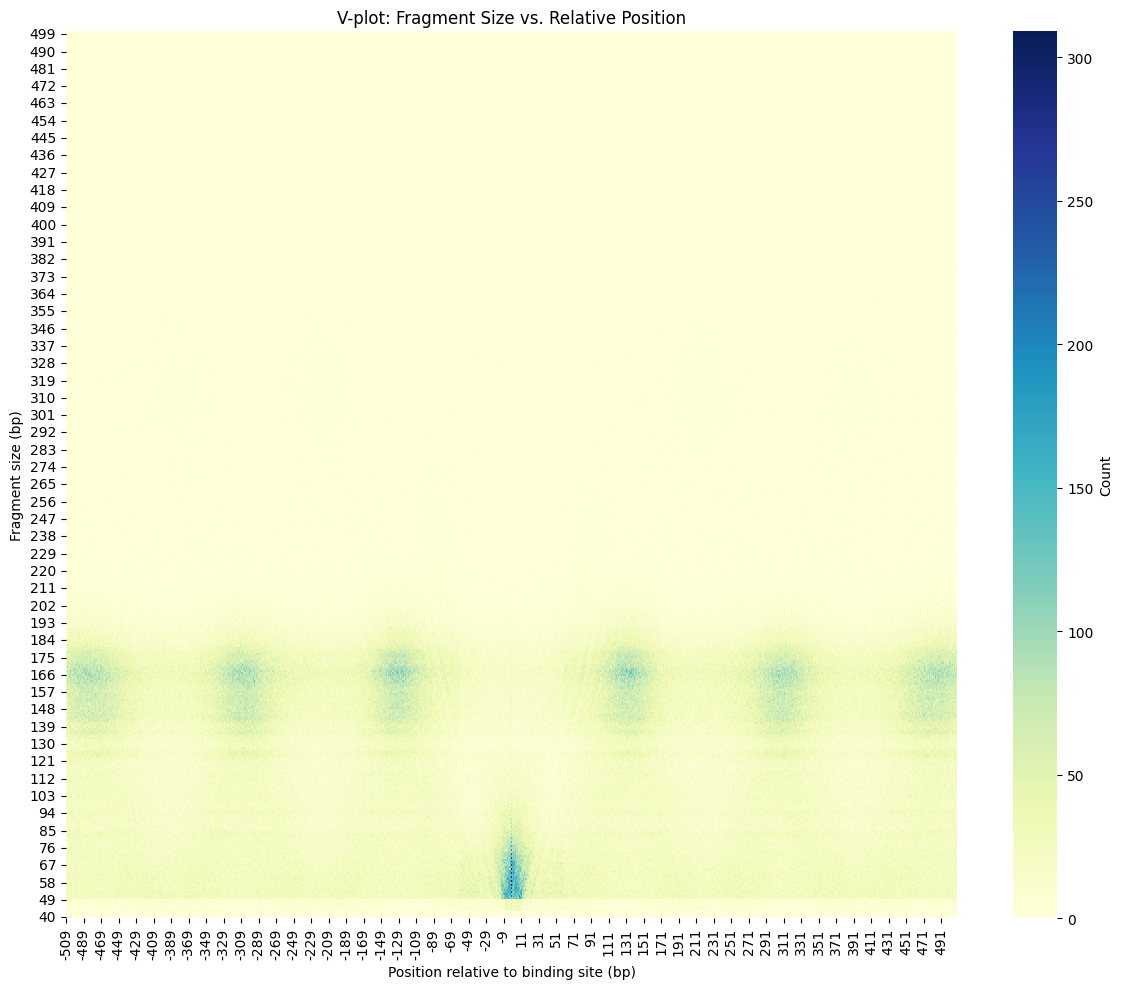

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Initialize counter for (X, Y) pairs
xy_counter = Counter()

# Parse BED file and collect X (center offset) and Y (fragment size)
with open('mapped.bed', 'r') as file:
    for line in file:
        fields = line.strip().split('\t')
        c1 = (int(fields[2]) + int(fields[3])) / 2
        c2 = (int(fields[8]) + int(fields[9])) / 2
        x = int(c2 - c1)
        y = int(fields[9]) - int(fields[8])
        xy_counter[(x, y)] += 1

print("Total unique (X, Y) pairs:", len(xy_counter))

# Prepare sorted unique values
x_vals = sorted(set(x for x, y in xy_counter))
y_vals = sorted(set(y for x, y in xy_counter))

# Fill matrix with counts
matrix = np.zeros((len(y_vals), len(x_vals)), dtype=int)
x_idx = {x: i for i, x in enumerate(x_vals)}
y_idx = {y: i for i, y in enumerate(y_vals)}

for (x, y), count in xy_counter.items():
    matrix[y_idx[y], x_idx[x]] = count

df_matrix = pd.DataFrame(matrix, index=y_vals, columns=x_vals)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_matrix, cmap='YlGnBu', cbar_kws={'label': 'Count'})
plt.gca().invert_yaxis()
plt.title("V-plot: Fragment Size vs. Relative Position")
plt.xlabel("Position relative to binding site (bp)")
plt.ylabel("Fragment size (bp)")
plt.tight_layout()
plt.show()
